# Explainable AI for Post-COVID Psychological Profile Prediction
## K6

This version was based on the Kaggle notebook by Amujoyegbe (2023). 

https://www.kaggle.com/code/feyiamujo/depression-stress-and-anxiety-prediction

# Data Preparation

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import pprint
import joblib as job
import time
import seaborn as sns

from scipy import stats
import sklearn.metrics as metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score 
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder

import shap

pp = pprint.PrettyPrinter(indent=1)

In [2]:
# Lucky number 8
random_state = 8

In [3]:
# Loading dataset for Wilcoxon Rank-Sum Test
df = pd.read_csv('../data/dataset_differences.csv')

df.head(10)

,SAMPLEID,K6_total_old,PHQ9_total_old,GAD7_total_old,SSS8_total_old,PTGI-X(Q7_22_27)_old,SHS_total_old,UCLA_total_old,LSNS6_total_old,AUDIT_old,...,AUDIT_new,K6_total_diff,PHQ9_total_diff,GAD7_total_diff,SSS8_total_diff,PTGI-X(Q7_22_27)_diff,SHS_total_diff,UCLA_total_diff,LSNS6_total_diff,AUDIT_diff
0,3793,4.0,5.0,4.0,13.0,0.0,1.50,40.0,4.0,4.0,...,6,8.0,10.0,10.0,5.0,19.0,2.50,-16.0,0.0,2.0
1,9703,0.0,0.0,0.0,1.0,7.0,4.00,10.0,17.0,0.0,...,0,1.0,0.0,0.0,0.0,-4.0,0.50,1.0,1.0,0.0
2,11532,24.0,0.0,0.0,4.0,0.0,4.50,31.0,4.0,0.0,...,0,-23.0,2.0,0.0,-3.0,0.0,-0.50,1.0,-4.0,0.0
3,15778,0.0,0.0,0.0,0.0,13.0,5.25,16.0,15.0,0.0,...,0,0.0,0.0,0.0,0.0,5.0,0.25,5.0,-2.0,0.0
4,18713,0.0,0.0,0.0,0.0,18.0,5.00,23.0,5.0,0.0,...,0,0.0,2.0,0.0,0.0,-3.0,0.25,-1.0,13.0,0.0
5,19076,3.0,4.0,1.0,3.0,18.0,3.50,25.0,6.0,4.0,...,5,-3.0,-4.0,-1.0,3.0,0.0,0.25,-1.0,-1.0,1.0
6,20396,0.0,0.0,0.0,3.0,18.0,3.75,25.0,3.0,12.0,...,13,0.0,0.0,0.0,2.0,-7.0,0.50,-2.0,0.0,1.0
7,22140,8.0,9.0,5.0,12.0,9.0,3.50,27.0,7.0,0.0,...,0,-2.0,-1.0,1.0,-2.0,0.0,-0.25,1.0,-1.0,0.0
8,23362,3.0,4.0,2.0,5.0,0.0,4.00,29.0,6.0,0.0,...,0,4.0,-1.0,0.0,6.0,6.0,0.25,0.0,0.0,0.0
9,27241,0.0,2.0,0.0,7.0,19.0,4.50,26.0,5.0,15.0,...,16,0.0,0.0,1.0,3.0,-3.0,-1.00,2.0,1.0,1.0


In [4]:
# Loading main dataset
dataset = pd.read_csv('../data/data.csv')

dataset.head(10)

,SAMPLEID,ANSWERDATE,5_SEX,5_AGE,5_PREFECTURE,5_MARRIED,5_CHILD,5_HINCOME,5_PINCOME,5_JOB,...,5_AUDIT_group,6_K6_total,6_PHQ9_total,6_GAD7_total,6_SSS8_total,6_PTGI-X(Q7_22_27),6_SHS_total,6_UCLA_total,6_LSNS6_total,6_AUDIT
0,1106,2022/05/13-19:39:52,1.0,67.0,14.0,2.0,2.0,3.0,1.0,12.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1759,2022/05/14-08:44:24,1.0,57.0,40.0,2.0,2.0,5.0,3.0,3.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1916,2022/05/13-20:19:11,1.0,62.0,11.0,2.0,2.0,2.0,2.0,3.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3793,2022/05/14-18:23:23,1.0,55.0,40.0,2.0,2.0,4.0,3.0,4.0,...,0.0,12.0,15.0,14.0,18.0,19.0,4.0,24.0,4.0,6.0
5,3827,2022/05/14-10:51:50,2.0,58.0,14.0,1.0,1.0,2.0,2.0,3.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,5765,2022/05/13-21:00:54,1.0,61.0,12.0,2.0,2.0,10.0,10.0,5.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8488,2022/05/13-21:47:57,2.0,59.0,27.0,2.0,1.0,10.0,1.0,8.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9703,2022/05/14-07:51:04,2.0,68.0,28.0,2.0,2.0,8.0,1.0,8.0,...,0.0,1.0,0.0,0.0,1.0,3.0,4.5,11.0,18.0,0.0
9,10761,2022/05/14-01:32:45,1.0,53.0,27.0,1.0,1.0,2.0,2.0,5.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Overview of data
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24050 entries, 0 to 24049
Data columns (total 99 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   SAMPLEID                 24050 non-null  int64  
 1   ANSWERDATE               16641 non-null  object 
 2   5_SEX                    16641 non-null  float64
 3   5_AGE                    16641 non-null  float64
 4   5_PREFECTURE             16641 non-null  float64
 5   5_MARRIED                16641 non-null  float64
 6   5_CHILD                  16641 non-null  float64
 7   5_HINCOME                16641 non-null  float64
 8   5_PINCOME                16641 non-null  float64
 9   5_JOB                    16641 non-null  float64
 10  5_STUDENT                16641 non-null  float64
 11  5_Number_fam             16641 non-null  float64
 12  5_SchoolGrade            16641 non-null  float64
 13  5_YearsEnrolled          16641 non-null  float64
 14  5_VacNum              

In [6]:
# Check for duplicates on each row
dataset.duplicated().value_counts()

False    24050
Name: count, dtype: int64

In [7]:
# Check for unique values
dataset.nunique()

SAMPLEID              24050
ANSWERDATE            14027
5_SEX                     2
5_AGE                    74
5_PREFECTURE             46
                      ...  
6_PTGI-X(Q7_22_27)       36
6_SHS_total              25
6_UCLA_total             31
6_LSNS6_total            31
6_AUDIT                  36
Length: 99, dtype: int64

## Data Preprocessing

In [8]:
# Sorting dataset based on SAMPLEID
dataset_sorted = dataset.sort_values(by=['SAMPLEID'])

dataset_sorted.head(10)

,SAMPLEID,ANSWERDATE,5_SEX,5_AGE,5_PREFECTURE,5_MARRIED,5_CHILD,5_HINCOME,5_PINCOME,5_JOB,...,5_AUDIT_group,6_K6_total,6_PHQ9_total,6_GAD7_total,6_SSS8_total,6_PTGI-X(Q7_22_27),6_SHS_total,6_UCLA_total,6_LSNS6_total,6_AUDIT
0,1106,2022/05/13-19:39:52,1.0,67.0,14.0,2.0,2.0,3.0,1.0,12.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16161,1171,2022/05/13-19:35:52,1.0,59.0,14.0,2.0,2.0,6.0,5.0,3.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16162,1263,2022/05/13-19:44:02,1.0,73.0,14.0,2.0,2.0,2.0,2.0,12.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14191,1346,2022/05/13-19:00:17,1.0,52.0,26.0,2.0,2.0,3.0,3.0,2.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18612,1398,2022/05/13-20:26:45,1.0,52.0,27.0,1.0,1.0,3.0,3.0,6.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1759,2022/05/14-08:44:24,1.0,57.0,40.0,2.0,2.0,5.0,3.0,3.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1916,2022/05/13-20:19:11,1.0,62.0,11.0,2.0,2.0,2.0,2.0,3.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3793,2022/05/14-18:23:23,1.0,55.0,40.0,2.0,2.0,4.0,3.0,4.0,...,0.0,12.0,15.0,14.0,18.0,19.0,4.0,24.0,4.0,6.0
5,3827,2022/05/14-10:51:50,2.0,58.0,14.0,1.0,1.0,2.0,2.0,3.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Dropping empty rows from sorted dataset
dataset_cleaned = dataset_sorted.dropna()

dataset_cleaned.head(10)

,SAMPLEID,ANSWERDATE,5_SEX,5_AGE,5_PREFECTURE,5_MARRIED,5_CHILD,5_HINCOME,5_PINCOME,5_JOB,...,5_AUDIT_group,6_K6_total,6_PHQ9_total,6_GAD7_total,6_SSS8_total,6_PTGI-X(Q7_22_27),6_SHS_total,6_UCLA_total,6_LSNS6_total,6_AUDIT
4,3793,2022/05/14-18:23:23,1.0,55.0,40.0,2.0,2.0,4.0,3.0,4.0,...,0.0,12.0,15.0,14.0,18.0,19.0,4.00,24.0,4.0,6.0
8,9703,2022/05/14-07:51:04,2.0,68.0,28.0,2.0,2.0,8.0,1.0,8.0,...,0.0,1.0,0.0,0.0,1.0,3.0,4.50,11.0,18.0,0.0
11,11532,2022/05/14-12:53:15,1.0,50.0,13.0,1.0,1.0,3.0,3.0,3.0,...,0.0,1.0,2.0,0.0,1.0,0.0,4.00,32.0,0.0,0.0
15,15778,2022/05/13-19:09:38,1.0,64.0,27.0,2.0,2.0,5.0,3.0,3.0,...,0.0,0.0,0.0,0.0,0.0,18.0,5.50,21.0,13.0,0.0
19,18713,2022/05/13-22:01:06,1.0,61.0,13.0,2.0,2.0,10.0,10.0,2.0,...,0.0,0.0,2.0,0.0,0.0,15.0,5.25,22.0,18.0,0.0
21,19076,2022/05/13-22:05:07,1.0,60.0,40.0,1.0,2.0,3.0,3.0,4.0,...,0.0,0.0,0.0,0.0,6.0,18.0,3.75,24.0,5.0,5.0
22,20396,2022/05/14-16:49:05,1.0,67.0,13.0,2.0,2.0,3.0,2.0,9.0,...,0.0,0.0,0.0,0.0,5.0,11.0,4.25,23.0,3.0,13.0
24,22140,2022/05/14-06:34:09,1.0,51.0,13.0,1.0,1.0,10.0,3.0,7.0,...,0.0,6.0,8.0,6.0,10.0,9.0,3.25,28.0,6.0,0.0
27,23362,2022/05/14-09:18:30,1.0,44.0,13.0,1.0,1.0,4.0,3.0,3.0,...,0.0,7.0,3.0,2.0,11.0,6.0,4.25,29.0,6.0,0.0
31,27241,2022/05/13-19:08:44,1.0,53.0,13.0,1.0,1.0,4.0,4.0,3.0,...,0.0,0.0,2.0,1.0,10.0,16.0,3.50,28.0,6.0,16.0


In [10]:
# Gathering columns
column_names = dataset_cleaned.columns.tolist()

In [11]:
# Setting attributes
attributes = dataset_cleaned.drop([
 'SAMPLEID',
 'ANSWERDATE',
 '5_PREFECTURE',
 '6_K6_total',
 '6_PHQ9_total',
 '6_GAD7_total',
 '6_SSS8_total',
 '6_PTGI-X(Q7_22_27)',
 '6_SHS_total',
 '6_UCLA_total',
 '6_LSNS6_total',
 '6_AUDIT'], axis=1)

num_attributes = len(attributes.columns.tolist())

attributes.head(10)

,5_SEX,5_AGE,5_MARRIED,5_CHILD,5_HINCOME,5_PINCOME,5_JOB,5_STUDENT,5_Number_fam,5_SchoolGrade,...,5_Mental_group,5_Covid_group,5_K6_group3,5_K6_group2,5_PHQ9_%,5_GAD_%,5_PHQ9_item9,5_PHQ9_SI,5_LSNS_group,5_AUDIT_group
4,1.0,55.0,2.0,2.0,4.0,3.0,4.0,0.0,2.0,0.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
8,2.0,68.0,2.0,2.0,8.0,1.0,8.0,0.0,3.0,0.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
11,1.0,50.0,1.0,1.0,3.0,3.0,3.0,0.0,0.0,0.0,...,4.0,4.0,3.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0
15,1.0,64.0,2.0,2.0,5.0,3.0,3.0,0.0,4.0,0.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
19,1.0,61.0,2.0,2.0,10.0,10.0,2.0,0.0,1.0,0.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
21,1.0,60.0,1.0,2.0,3.0,3.0,4.0,0.0,0.0,0.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
22,1.0,67.0,2.0,2.0,3.0,2.0,9.0,0.0,1.0,0.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
24,1.0,51.0,1.0,1.0,10.0,3.0,7.0,0.0,1.0,0.0,...,4.0,4.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0
27,1.0,44.0,1.0,1.0,4.0,3.0,3.0,0.0,2.0,0.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
31,1.0,53.0,1.0,1.0,4.0,4.0,3.0,0.0,0.0,0.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [12]:
# Setting target for K6
target_name = '6_K6_total'
target = dataset_cleaned[[target_name]]

target.head(10)

,6_K6_total
4,12.0
8,1.0
11,1.0
15,0.0
19,0.0
21,0.0
22,0.0
24,6.0
27,7.0
31,0.0


## K6 Dataset

In [13]:
# Declaring function for K6
labels = ['Low distress', 'Likely distress']

def condition(x):
    if 0 <= x <= 4:
        return labels[0]
    elif 5 <= x <= 24:
        return labels[1]

In [14]:
target_column = target[[target_name]].rename(columns={target_name: 'target'})
attributes.columns = attributes.columns.str.lower().str.replace('^5_', '', regex=True)
pp_data = pd.concat([attributes, target_column], axis=1)

pp_data.head(10)

,sex,age,married,child,hincome,pincome,job,student,number_fam,schoolgrade,...,covid_group,k6_group3,k6_group2,phq9_%,gad_%,phq9_item9,phq9_si,lsns_group,audit_group,target
4,1.0,55.0,2.0,2.0,4.0,3.0,4.0,0.0,2.0,0.0,...,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,12.0
8,2.0,68.0,2.0,2.0,8.0,1.0,8.0,0.0,3.0,0.0,...,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
11,1.0,50.0,1.0,1.0,3.0,3.0,3.0,0.0,0.0,0.0,...,4.0,3.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
15,1.0,64.0,2.0,2.0,5.0,3.0,3.0,0.0,4.0,0.0,...,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
19,1.0,61.0,2.0,2.0,10.0,10.0,2.0,0.0,1.0,0.0,...,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
21,1.0,60.0,1.0,2.0,3.0,3.0,4.0,0.0,0.0,0.0,...,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
22,1.0,67.0,2.0,2.0,3.0,2.0,9.0,0.0,1.0,0.0,...,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
24,1.0,51.0,1.0,1.0,10.0,3.0,7.0,0.0,1.0,0.0,...,4.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,6.0
27,1.0,44.0,1.0,1.0,4.0,3.0,3.0,0.0,2.0,0.0,...,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,7.0
31,1.0,53.0,1.0,1.0,4.0,4.0,3.0,0.0,0.0,0.0,...,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [15]:
# Creating features list
features_list = attributes.columns.tolist()
features_list

['sex',
 'age',
 'married',
 'child',
 'hincome',
 'pincome',
 'job',
 'student',
 'number_fam',
 'schoolgrade',
 'yearsenrolled',
 'vacnum',
 'ukrainemoviepicture',
 'ukrainereadlisten',
 'med_self',
 'medself_covid',
 'med_fam',
 'medfam_covid',
 'current_physical',
 'past_physical',
 'current_mental',
 'past_mental',
 'current_covid19',
 'past_covid19',
 'k6_total',
 'phq9_total',
 'gad7_total',
 'sss8_total',
 'ptgi-x(q7_39_44)',
 'maia_1',
 'maia_2',
 'maia_3',
 'maia_4',
 'maia_5',
 'maia_6',
 'maia_7',
 'maia_8',
 'shs_total',
 'ucla_total',
 'lsns6_total',
 'audit',
 'exercise',
 'healthydiet',
 'favoriteactivity',
 'interaction_offline',
 'interaction_online',
 'pb_continuous',
 'pb_altruistic',
 'pb_avoidant',
 'trust_gov',
 'trust_sm',
 'vaccination_will',
 'pb_understanding',
 'optimism',
 'healthysleep',
 'deteriorationeconomy',
 'deteriorationinteract',
 'frustration',
 'covidanxiety',
 'covidsleepless',
 'difficultyliving',
 'difficultywork',
 'ptg1_s22',
 'ptg2_s23',
 '

In [16]:
pp_data['target_applied'] = pp_data['target'].apply(condition)
label_counts = pp_data['target_applied'].value_counts()

print(label_counts)

target_applied
Low distress       1903
Likely distress     756
Name: count, dtype: int64


In [17]:
le = LabelEncoder()
pp_data['target_encoded'] = le.fit_transform(pp_data['target_applied'])
pp_data

,sex,age,married,child,hincome,pincome,job,student,number_fam,schoolgrade,...,k6_group2,phq9_%,gad_%,phq9_item9,phq9_si,lsns_group,audit_group,target,target_applied,target_encoded
4,1.0,55.0,2.0,2.0,4.0,3.0,4.0,0.0,2.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,12.0,Likely distress,0
8,2.0,68.0,2.0,2.0,8.0,1.0,8.0,0.0,3.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,Low distress,1
11,1.0,50.0,1.0,1.0,3.0,3.0,3.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,Low distress,1
15,1.0,64.0,2.0,2.0,5.0,3.0,3.0,0.0,4.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,Low distress,1
19,1.0,61.0,2.0,2.0,10.0,10.0,2.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,Low distress,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11204,1.0,55.0,1.0,2.0,2.0,2.0,3.0,0.0,3.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,12.0,Likely distress,0
11208,1.0,53.0,2.0,2.0,7.0,7.0,3.0,0.0,2.0,0.0,...,2.0,1.0,1.0,2.0,1.0,1.0,0.0,0.0,Low distress,1
11209,2.0,48.0,2.0,1.0,5.0,1.0,8.0,0.0,1.0,0.0,...,2.0,0.0,0.0,1.0,1.0,1.0,0.0,13.0,Likely distress,0
11288,2.0,31.0,1.0,1.0,3.0,3.0,3.0,0.0,0.0,0.0,...,2.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,Low distress,1


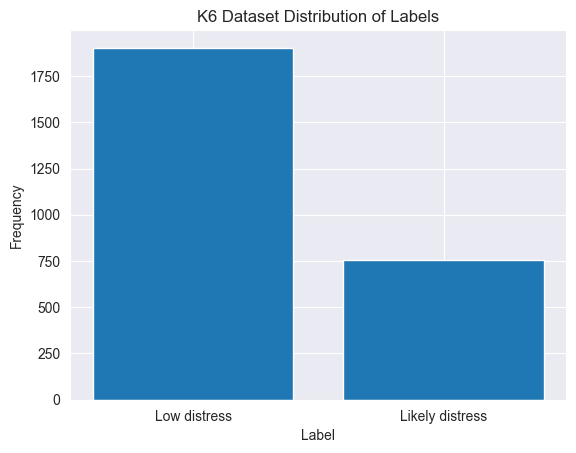

In [18]:
# Plot the bar chart
plt.bar(label_counts.index, label_counts.values)

# Add labels and title
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.title('K6 Dataset Distribution of Labels')

# Show the plot
plt.show()

## Stat tests

In [19]:
# K6
X = np.array(df.K6_total_old)
Y = np.array(df.K6_total_new)
res = stats.wilcoxon(X, Y, alternative='two-sided')

res

WilcoxonResult(statistic=np.float64(575312.0), pvalue=np.float64(0.007354128804346646))

In [20]:
# K6
X = np.array(df.K6_total_old)
Y = np.array(df.K6_total_new)
res = stats.wilcoxon(X, Y, alternative='greater')

res

WilcoxonResult(statistic=np.float64(672098.0), pvalue=np.float64(0.003677064402173323))

In [21]:
# K6
X = np.array(df.K6_total_old)
Y = np.array(df.K6_total_new)
res = stats.wilcoxon(X, Y, alternative='less')

res

WilcoxonResult(statistic=np.float64(672098.0), pvalue=np.float64(0.9963229355978267))

K6: 0 to 24 (Kessler et al., 2010)
    0-12: Unlikely distress
    13-24: Likely distress

Null Hypothesis: There is no significant difference in K6 scores during the COVID-19 pandemic and after it.

Alternative Hypothesis:
Defining the two-sided test:
There is a significant difference in K6 scores during the COVID-19 pandemic and after it.
Defining the one-sided tests:
alternative=’greater’: We expect K6 scores to be generally higher after COVID-19
alternative=’less’: We expect K6 scores to be generally less after COVID-19

Running the tests:
Two-sided
WilcoxonResult(statistic=575312.0, pvalue=0.007354128804346646)
The test yielded a test statistic of 575312.0 and a p-value of 0.007354128804346646.

Since the p-value is below the 0.05 threshold, we reject the null hypothesis, indicating a statistically significant difference in K6 scores during the COVID-19 pandemic and after it.


One-sided -> greater
WilcoxonResult(statistic=672098.0, pvalue=0.003677064402173323)
The test yielded a test statistic of 672098.0 and a p-value of 0.003677064402173323.

Since the p-value is below the 0.05 threshold, we reject the null hypothesis, indicating a statistically significant increase in K6 scores after the COVID-19 pandemic.


One-sided -> less
WilcoxonResult(statistic=672098.0, pvalue=0.9963229355978267)
The test yielded a test statistic of 672098.0 and a p-value of 0.9963229355978267.

Since the p-value is above the 0.05 threshold, we accept the null hypothesis, indicating no significant difference in K6 scores during the COVID-19 pandemic and after it.

# Generating the training and test set for each dataset

In [22]:
# Extract the target and features
y = pp_data['target_encoded']
X = pp_data.drop(columns=['target', 'target_applied', 'target_encoded'])

In [23]:
y.value_counts()

target_encoded
1    1903
0     756
Name: count, dtype: int64

In [24]:
#Get the training and test set from the K6 dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state= 30)

# Calculate the count of each unique label
unique_labels, label_counts = np.unique(y_test, return_counts=True)

print("Test data distribution")
# Print the label counts
for label, count in zip(unique_labels, label_counts):
    print(f"Label: {label}, Count: {count}")

Test data distribution
Label: 0, Count: 231
Label: 1, Count: 567


# Model Training
## Random Forest Classification

In [25]:
model = RandomForestClassifier(random_state=random_state)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=8)

In [26]:
predictions = model.predict(X_test)

[[151  80]
 [ 56 511]]


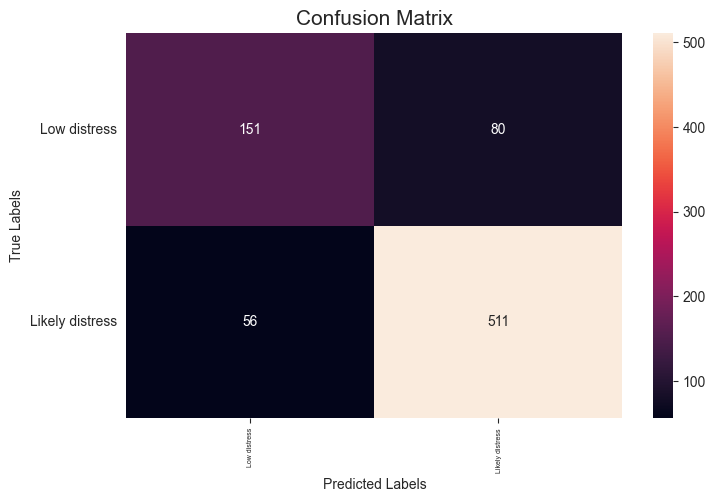

In [27]:
#Confusion matrix
cm = confusion_matrix(y_test, predictions)
print(cm)

#Plot the Confusion matrix graph
fig = plt.figure(figsize=(8, 5))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g')
ax.set_xlabel('Predicted Labels', fontsize=10)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(labels, fontsize=5)
ax.xaxis.tick_bottom()

ax.set_ylabel('True Labels', fontsize=10)
ax.yaxis.set_ticklabels(labels, fontsize=10)
plt.yticks(rotation=0)

plt.title('Confusion Matrix', fontsize=15)

plt.show()

In [28]:
#Classification report
print(classification_report(y_test, predictions, target_names = labels))

                 precision    recall  f1-score   support

   Low distress       0.73      0.65      0.69       231
Likely distress       0.86      0.90      0.88       567

       accuracy                           0.83       798
      macro avg       0.80      0.78      0.79       798
   weighted avg       0.83      0.83      0.83       798



In [29]:
# Evaluate the model using accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, average='macro')
recall = recall_score(y_test, predictions, average='macro')
f1 = f1_score(y_test, predictions, average='macro')


# Print the evaluation metrics
print("Accuracy: %.f" %(accuracy*100))
print("Precision: %.f" %(precision*100))
print("Recall: %.f" %(recall*100))
print("F1-score: %.f" %(f1*100))

Accuracy: 83
Precision: 80
Recall: 78
F1-score: 79


## Hyperparameter Tuning

In [30]:
# Define hyperparameter space
n_estimators = [100, 250, 500, 1000]                       # Range of trees
max_features = ['sqrt', 'log2']                 # Feature selection
max_depth = [int(x) for x in np.linspace(10, 100, num=10)]
max_depth.append(None) # Depth
min_samples_split = [2, 5, 10, 15]                     # Control overfitting
min_samples_leaf = [1, 2, 4, 6]                       # Prevent overfitting
bootstrap = [True, False]                              # Sampling strategy
class_weight = ['balanced', None]               # Handling of imbalanced classes
cv = 10                                         # Cross-validation folds

# Create the random grid
random_grid = {
    'n_estimators': n_estimators,
    'max_features': max_features,
    'max_depth': max_depth,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf,
    'bootstrap': bootstrap,
    'class_weight': class_weight
}

print('Hyperparameter search space:')
pp.pprint(random_grid)

# Set the hyperparameter tuner
start_time = time.time()
model = RandomForestClassifier(verbose=0)

# Randomized Search CV
print("\nStarting Randomized Search CV...")
tuner = RandomizedSearchCV(estimator=model, 
                           param_distributions=random_grid, 
                           n_iter=200, 
                           cv=10, 
                           scoring='r2', 
                           random_state=random_state, 
                           verbose=1, 
                           return_train_score=True, 
                           n_jobs=10)

# Fit the random search model
print("Fitting the Randomized Search model...")
tuner.fit(X_train, y_train)
print("Randomized Search CV completed.")

# Time taken for Randomized Search
end_time = time.time()
running_time = end_time - start_time
print('\nRandom Forest training time:', running_time, 's')

# Now, if you want to continue with Grid Search
print("\nStarting Grid Search CV...")
tuner_grid = GridSearchCV(estimator=model, 
                          param_grid=random_grid, 
                          cv=cv, 
                          scoring='r2', 
                          verbose=6, 
                          return_train_score=True, 
                          n_jobs=10)

# Fit the grid search model
print("Fitting the Grid Search model...")
tuner_grid.fit(X_train, y_train)
print("Grid Search CV completed.")

# Time taken for Grid Search
end_time_grid = time.time()
running_time_grid = end_time_grid - end_time
print('\nGrid Search training time:', running_time_grid, 's')

Hyperparameter search space:
{'bootstrap': [True],
 'class_weight': ['balanced', None],
 'max_depth': [10, 50, None],
 'max_features': ['sqrt', 'log2'],
 'min_samples_leaf': [1, 4],
 'min_samples_split': [2, 10],
 'n_estimators': [100, 500]}

Starting Randomized Search CV...
Fitting the Randomized Search model...
Fitting 10 folds for each of 96 candidates, totalling 960 fits


E:\py3-10\lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 96 is smaller than n_iter=100. Running 96 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Randomized Search CV completed.

Random Forest training time: 101.9507908821106 s

Starting Grid Search CV...
Fitting the Grid Search model...
Fitting 10 folds for each of 96 candidates, totalling 960 fits
Grid Search CV completed.

Grid Search training time: 103.82223725318909 s


In [31]:
# Save the model
model_name = type(tuner).__name__
file_name = model_name + '_' + time.strftime("%Y%m%d-%H%M%S") + '.mod'
file_save = file_name

print('Saving', model_name, 'model as', file_name, '...')
job.dump(tuner, file_save) 

Saving RandomizedSearchCV model as RandomizedSearchCV_20241105-113336.mod ...


['RandomizedSearchCV_20241105-113336.mod']

In [32]:
# Load the model
file_model = 'RandomizedSearchCV_20241105-113336.mod'
file_load = file_model

saved_model = job.load(file_load) 
tuner = saved_model

print('Best hyperparameters:')
pp.pprint(tuner.best_estimator_.get_params())

Best hyperparameters:
{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': 50,
 'max_features': 'log2',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 4,
 'min_samples_split': 10,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 500,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}


In [33]:
# Check the tuned model
print('Best hyperparameters:')
print(tuner.best_estimator_)

Best hyperparameters:
RandomForestClassifier(class_weight='balanced', max_depth=50,
                       max_features='log2', min_samples_leaf=4,
                       min_samples_split=10, n_estimators=500)


## Cross-validation Results

{'n_estimators': [100, 500], 'max_features': ['sqrt', 'log2'], 'max_depth': [10, 50, None], 'min_samples_split': [2, 10], 'min_samples_leaf': [1, 4], 'bootstrap': [True], 'class_weight': ['balanced', None]}
n_estimators = 100 : 0.1580096794012631
n_estimators = 500 : 0.15816993615084232
max_features = sqrt : 0.15844433805089828
max_features = log2 : 0.1577352775012072
max_depth = 10 : 0.15833718719252277
max_depth = 50 : 0.158023554906128
max_depth = None : 0.15790868122950744
min_samples_split = 2 : 0.15690011728761946
min_samples_split = 10 : 0.15927949826448598
min_samples_leaf = 1 : 0.15501101413105922
min_samples_leaf = 4 : 0.16116860142104622
bootstrap = True : 0.15808980777605272
class_weight = balanced : 0.1554961174476713
class_weight = None : 0.16068349810443416


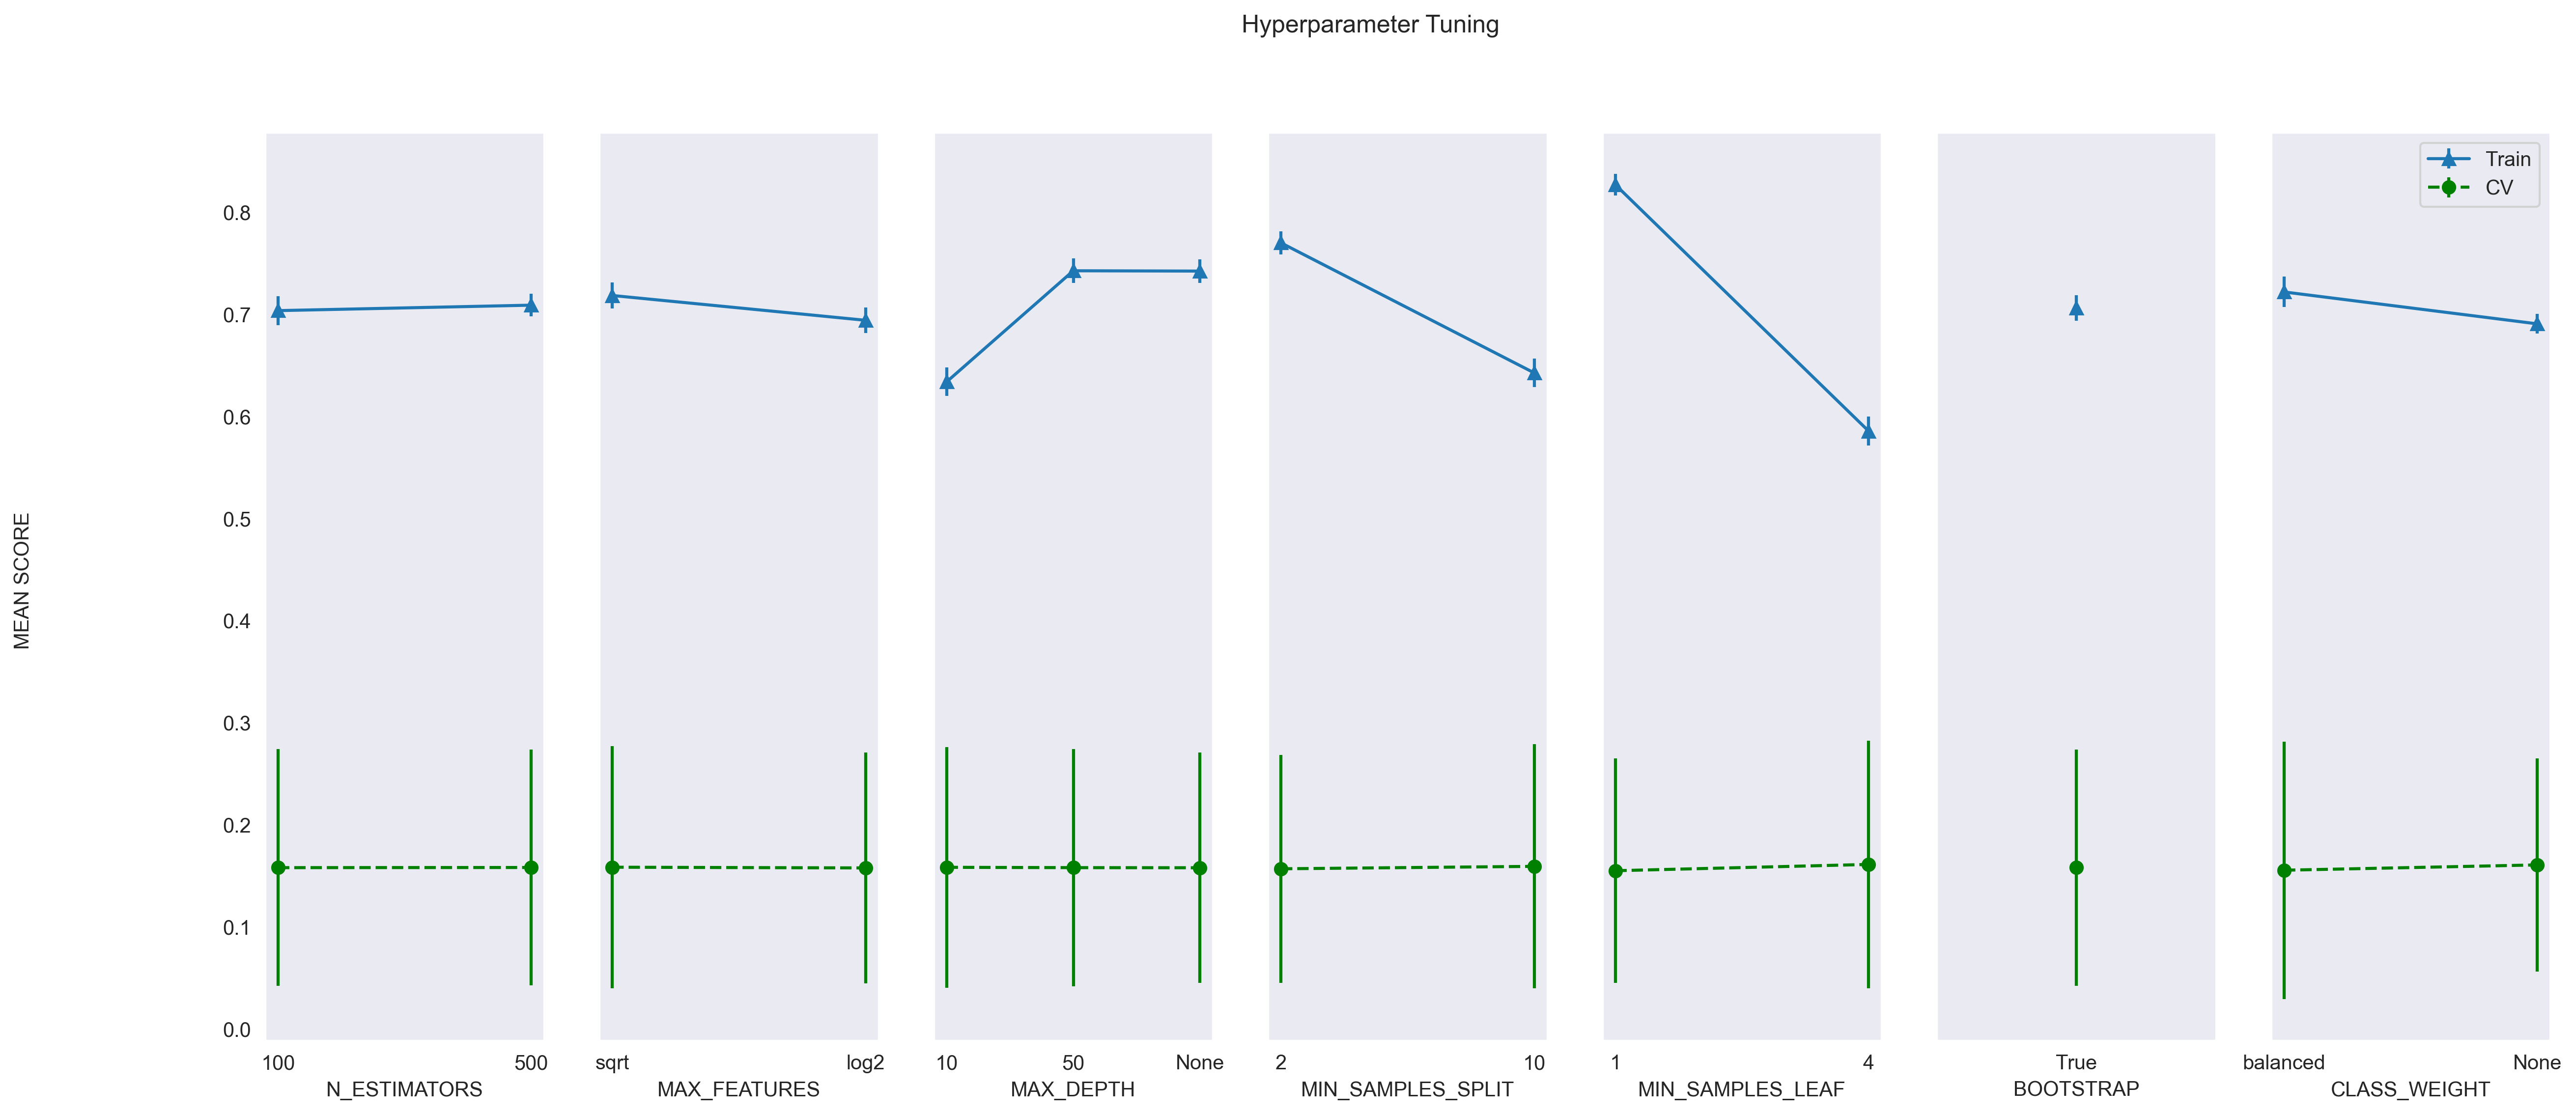

{'mean_fit_time': array([0.35366743, 1.54354188, 0.31509321, 1.4725765 , 0.29951041,
       1.4175878 , 0.2783603 , 1.36849132, 0.27710712, 1.29883571,
       0.24361098, 1.22107568, 0.24877806, 1.19942572, 0.23403909,
       1.21419842, 0.37424068, 1.78922031, 0.33971732, 1.72696781,
       0.3174155 , 1.55030546, 0.30019295, 1.50512295, 0.29142015,
       1.45075605, 0.25971887, 1.28247228, 0.25540552, 1.33582313,
       0.24396684, 1.18886716, 0.35409279, 1.72668984, 0.31299236,
       1.58419437, 0.33467612, 1.624313  , 0.29876797, 1.44324462,
       0.28633637, 1.41323376, 0.26893365, 1.27506723, 0.24808342,
       1.27823868, 0.33882232, 1.76864321, 0.31712968, 1.52450166,
       0.30540359, 1.53208883, 0.3567004 , 1.63760662, 0.30409069,
       1.45476229, 0.25565655, 1.30872059, 0.25814946, 1.24821534,
       0.24450455, 1.20334721, 0.23916609, 1.68479488, 0.45494411,
       2.10400321, 0.35886989, 2.13621719, 0.3520144 , 1.85075231,
       0.64777553, 1.93567705, 0.55576873, 1

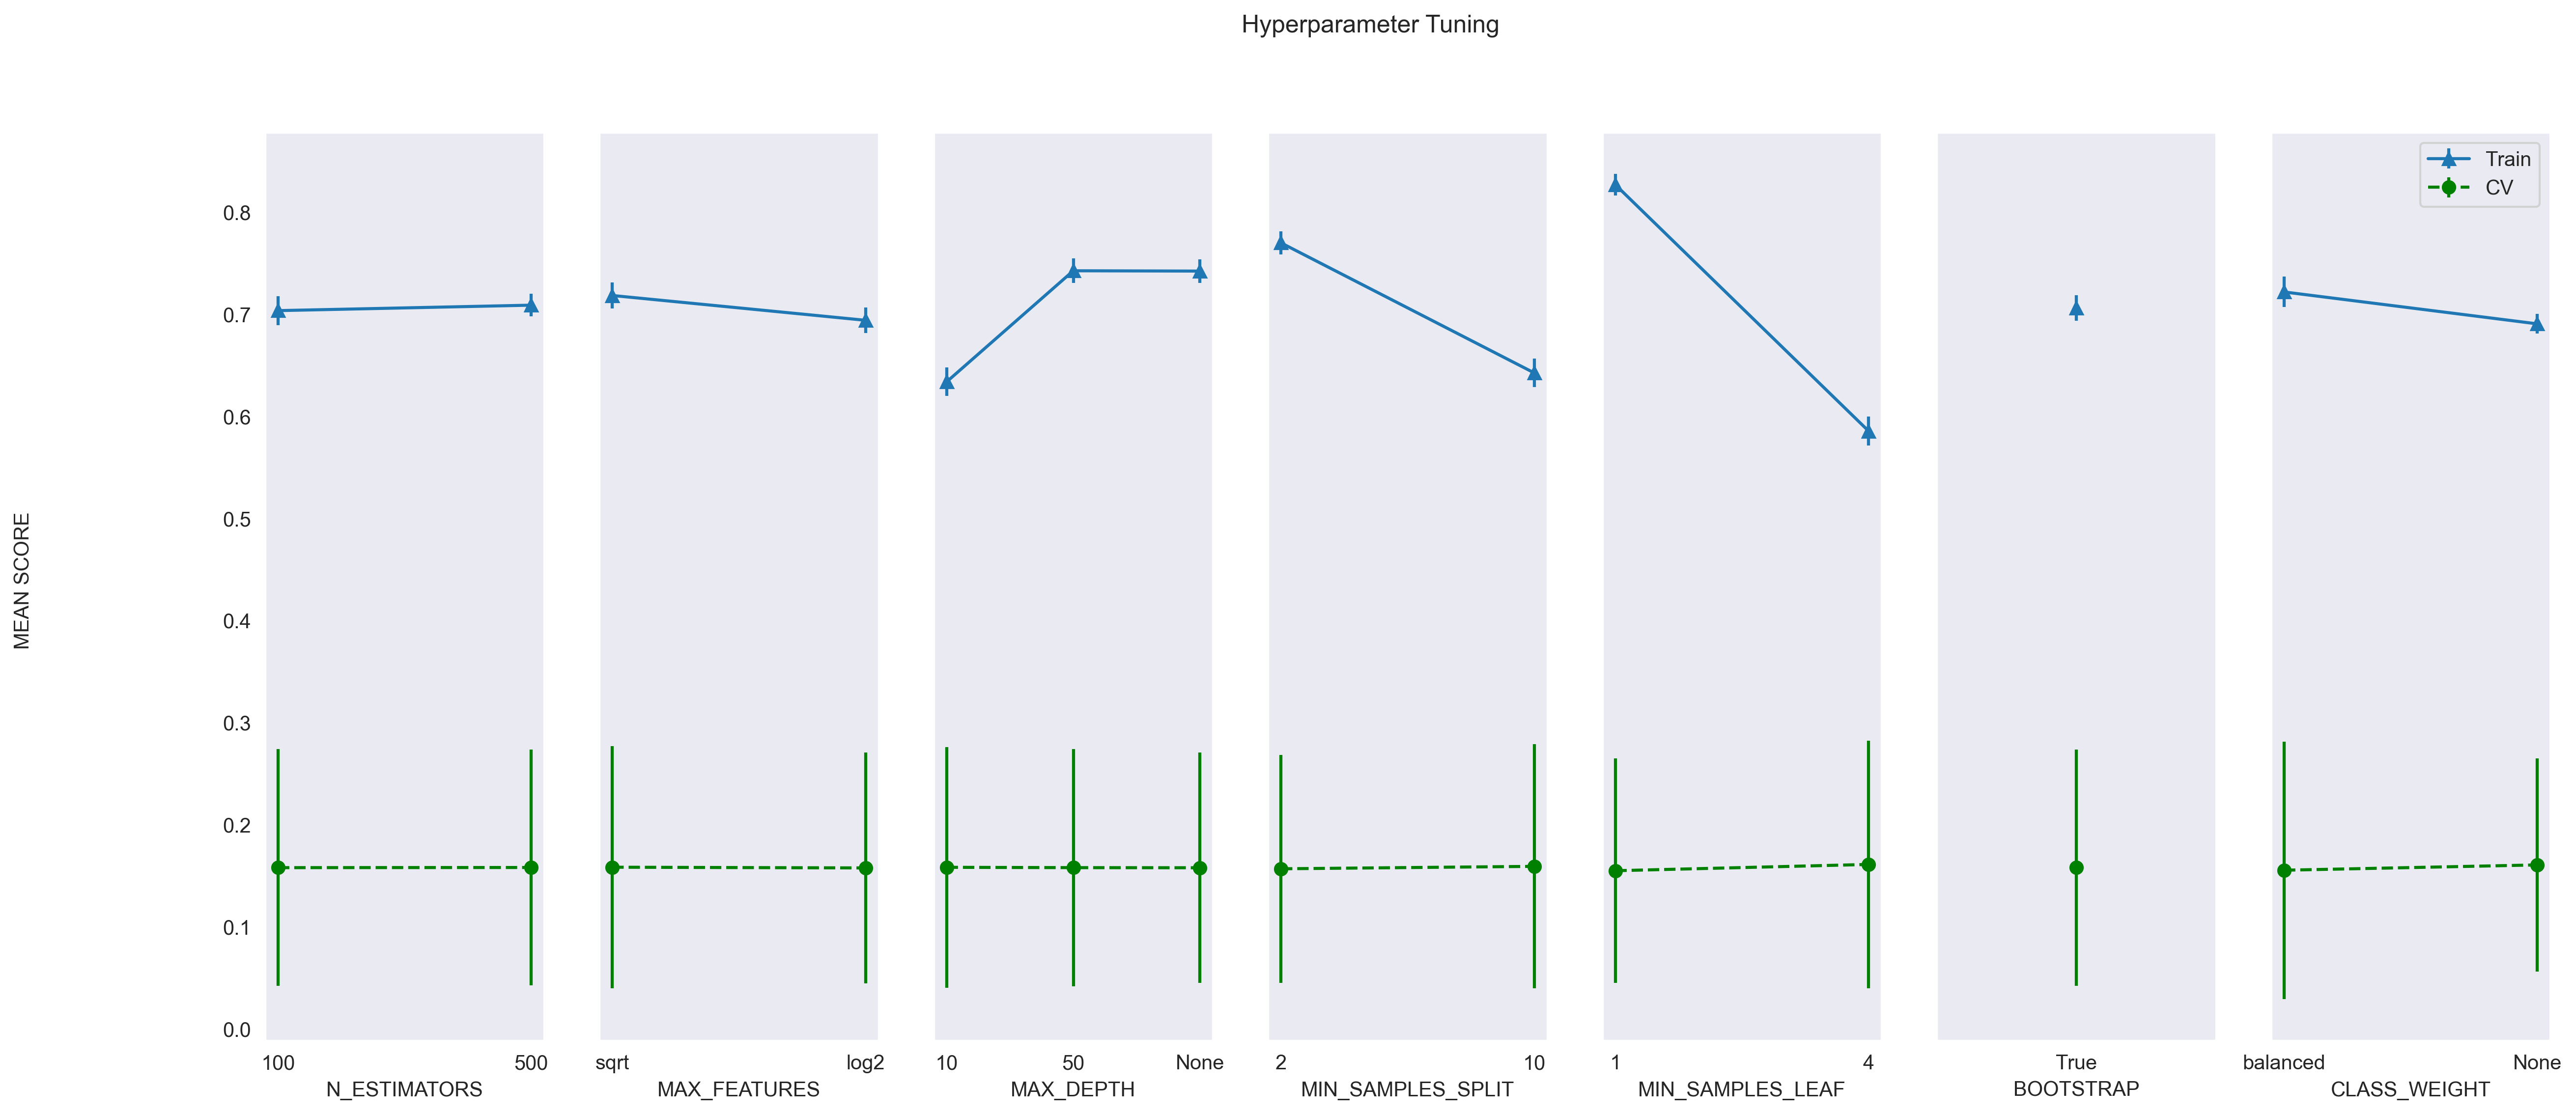

In [34]:
## Plot CV results
def plot_cv(tuner):
    results = tuner.cv_results_
    cv_params = tuner.param_distributions
    means_test = results['mean_test_score']
    stds_test = results['std_test_score']
    means_train = results['mean_train_score']
    stds_train = results['std_train_score']

    print(cv_params)
    fig, ax = plt.subplots(1, len(cv_params), sharex='none', sharey='all', figsize=(20,8), dpi=300)
    fig.suptitle('Hyperparameter Tuning')
    fig.text(0.04, 0.5, 'MEAN SCORE', va='center', rotation='vertical')

    scores = {}
    for i, (param, param_val) in enumerate(cv_params.items()):
        x, y1, e1, y2, e2 = [], [], [], [], []

        for v in param_val:
            mask_idx = results['param_'+param]==v
            v = str(v)

            m_train = np.mean(means_train[mask_idx])
            s_train = np.sqrt(np.mean(stds_train[mask_idx]**2))
            m_test = np.mean(means_test[mask_idx])    
            s_test = np.sqrt(np.mean(stds_test[mask_idx]**2))

            scores[param+'='+v+'_means_train'] = m_train
            scores[param+'='+v+'_stds_train'] = s_train    
            scores[param+'='+v+'_means_test'] = m_test
            scores[param+'='+v+'_stds_test'] = s_test
            print(param, "=", v, ":", m_test)

            x.append(v)
            y1.append(m_train)
            e1.append(s_train) 
            y2.append(m_test) 
            e2.append(s_test)

        ax[i].errorbar(x, y1, e1, linestyle='-', marker='^', label='Train')
        ax[i].errorbar(x, y2, e2, linestyle='--', marker='o', color='g', label='CV')
        ax[i].set_xlabel(param.upper())

    # pp.pprint(scores)

    plt.legend()
    plt.show()

sns.set_style('dark')
plot_cv(tuner)
print(tuner.cv_results_)
plot_cv(saved_model)

In [35]:
## Evaluate model
def evaluate(model, X, y_actual):
    y_predicted = model.predict(X)
    mae = metrics.mean_absolute_error(y_actual, y_predicted)
    mse = metrics.mean_squared_error(y_actual, y_predicted)
    rmse = np.sqrt(mse)
    re = np.divide(np.abs(y_actual - y_predicted), y_actual) * 100
    mre = np.mean(re)
    r2 = model.score(X, y_actual)

    print('Model Performance')
    print('MAE: {:0.4f}'.format(mae))
    print('MSE: {:0.4f}'.format(mse))
    print('RMSE: {:0.4f}'.format(rmse))
    print('MRE: {:0.4f}%'.format(mre))
    print('R2: {:0.4f}'.format(r2))
    
    return r2

print('Base model')
base_model = RandomForestClassifier(random_state=random_state)
base_model.fit(X_train, y_train)
base_accuracy = evaluate(base_model, X_test, y_test)

print('\nTuned model')
tuned_model = tuner.best_estimator_
tuned_accuracy = evaluate(tuned_model, X_test, y_test)

print('\nSaved model')
saved_accuracy = evaluate(saved_model.best_estimator_, X_test, y_test)

print('\nImprovement: {:0.2f}'.format(tuned_accuracy - base_accuracy))

Base model
Model Performance
MAE: 0.1704
MSE: 0.1704
RMSE: 0.4128
MRE: inf%
R2: 0.8296

Tuned model
Model Performance
MAE: 0.1779
MSE: 0.1779
RMSE: 0.4218
MRE: inf%
R2: 0.8221

Saved model
Model Performance
MAE: 0.1779
MSE: 0.1779
RMSE: 0.4218
MRE: inf%
R2: 0.8221

Improvement: -0.01


In [ ]:
predictions = tuned_model.predict(X_test)

In [ ]:
#Confusion matrix
cm = confusion_matrix(y_test, predictions)
print(cm)

#Plot the Confusion matrix graph
fig = plt.figure(figsize=(8, 5))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g')
ax.set_xlabel('Predicted Labels', fontsize=10)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(labels, fontsize=5)
ax.xaxis.tick_bottom()

ax.set_ylabel('True Labels', fontsize=10)
ax.yaxis.set_ticklabels(labels, fontsize=10)
plt.yticks(rotation=0)

plt.title('Confusion Matrix', fontsize=15)

plt.show()

In [ ]:
#Classification report
print(classification_report(y_test, predictions, target_names = labels))

In [ ]:
# Evaluate the model using accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, average='macro')
recall = recall_score(y_test, predictions, average='macro')
f1 = f1_score(y_test, predictions, average='macro')


# Print the evaluation metrics
print("Accuracy: %.f" %(accuracy*100))
print("Precision: %.f" %(precision*100))
print("Recall: %.f" %(recall*100))
print("F1-score: %.f" %(f1*100))

# Prediction Probabilities

In [ ]:
y_predict_proba = model.predict_proba(X_test)
plt.figure(figsize=(10, 6))
sns.histplot(y_predict_proba.max(axis=1), bins=20, kde=True)
plt.xlabel("Maximum Predicted Probability")
plt.ylabel("Frequency")
plt.title("Prediction Confidence Distribution")
plt.show()

# Model Expalanation

In [ ]:
# Calculate SHAP
explainer = shap.TreeExplainer(model)

In [ ]:
shap_values = explainer.shap_values(X_train)
shap_test_values = explainer.shap_values(X_test)

In [ ]:
# Define paths for saving
explainer_path = "explainer.pkl"
shap_values_train_path = "shap_values_train.pkl"
shap_values_test_path = "shap_values_test.pkl"

In [ ]:
# Save the explainer
with open(explainer_path, "wb") as f:
    pickle.dump(explainer, f)

# Save the SHAP values for training and test data
with open(shap_values_train_path, "wb") as f:
    pickle.dump(shap_values, f)

with open(shap_values_test_path, "wb") as f:
    pickle.dump(shap_test_values, f)

In [ ]:
# Load the explainer
with open(explainer_path, "rb") as f:
    explainer = pickle.load(f)

# Load the SHAP values for training and test data
with open(shap_values_train_path, "rb") as f:
    shap_values = pickle.load(f)

with open(shap_values_test_path, "rb") as f:
    shap_test_values = pickle.load(f)


## Feature Importance

In [ ]:
# Get the class names in the correct order using inverse_transform
class_names = le.inverse_transform(range(len(le.classes_)))

In [ ]:
# Plot SHAP values for each class without manually specifying `n`
for i, class_name in enumerate(class_names):
    print(f"SHAP summary plot for class: {class_name}")
    shap.summary_plot(shap_values[:, :, i], X_train, feature_names=features_list, plot_type="bar")

In [ ]:
# Feature Effects
for i, class_name in enumerate(class_names):
    print(f"SHAP summary plot for class: {class_name}")
    shap.summary_plot(shap_values[:, :, i], X_train, feature_names=features_list)

In [ ]:
# Dependence
print('Interaction values')
shap_interaction_values = explainer.shap_interaction_values(X_test)
print(shap_interaction_values)

In [ ]:
# Define a path for the interaction values
shap_interaction_values_test_path = "shap_interaction_values_test.pkl"

In [ ]:
# Save the SHAP interaction values for the test data
with open(shap_interaction_values_test_path, "wb") as f:
    pickle.dump(shap_interaction_values, f)

In [ ]:
# Load the SHAP interaction values for the test data
with open(shap_interaction_values_test_path, "rb") as f:
    shap_interaction_values = pickle.load(f)

In [ ]:
# Define number of rows and columns for the grid
n_features = len(features_list)
n_cols = len(class_names)
n_rows = (n_features * 2 + n_cols - 1) // n_cols  # 2 plots per feature (one for each class)

# Set up the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()  # Flatten to make indexing easier

# Loop over features to plot both classes
for idx, ft in enumerate(features_list):
    # Plot dependence for the first class
    shap.dependence_plot(
        ft, shap_values[:, :, 0], X_train, ax=axes[idx * 2], show=False
    )
    axes[idx * 2].set_title(f"{ft} (Class 0)")

    # Plot dependence for the second class
    shap.dependence_plot(
        ft, shap_values[:, :, 1], X_train, ax=axes[idx * 2 + 1], show=False
    )
    axes[idx * 2 + 1].set_title(f"{ft} (Class 1)")

# Adjust layout and display
plt.tight_layout()
plt.show()


In [ ]:
# Additive Force
# Set sample index
i = 0  # Sample index

# Plot the force plot for the i-th sample and the second class
shap.force_plot(
    explainer.expected_value[1],  # Expected value for the second class
    shap_values[i, :, 1],         # SHAP values for the i-th sample, second class
    X_test.iloc[i],                # Features of the i-th sample
    feature_names=features_list,
    matplotlib=True
)

# Print sample details and SHAP values
print("Sample:", X_train.iloc[i])
print("\nSHAP Expected value for second class: %.2f" % explainer.expected_value[1])
print("Actual value: %.2f" % y_train.iloc[i])

# Extract the predicted value safely
predicted_value = tuned_model.predict(pd.DataFrame(X_train.iloc[i]).T)[0]  # Extract the first element
print("Predicted value: %.2f" % predicted_value)


In [ ]:
# Random Forest Visualization
# By Piotr Płoński
# https://mljar.com/blog/visualize-tree-from-random-forest/
import dtreeviz
from sklearn import tree

plt.figure()
tree.plot_tree(model.estimators_[0], feature_names=features_list, filled=True, fontsize=6)
plt.savefig('tree_high_dpi')

https://www.kaggle.com/code/vikumsw/explaining-random-forest-model-with-shapely-values

https://medium.com/biased-algorithms/shap-values-for-random-forest-1150577563c9

https://maxsteele731.medium.com/shap-force-plots-for-classification-d30be430e195

# Dashboard

http://titanicexplainer.herokuapp.com/multiclass

https://towardsdatascience.com/explainable-ai-xai-a-guide-to-7-packages-in-python-to-explain-your-models-932967f0634b

https://arxiv.org/abs/2005.12483

https://cran.r-project.org/web/packages/randomForestExplainer/

https://christophm.github.io/interpretable-ml-book/local-methods.html